In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Dense
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


TensorFlow: 2.19.0


In [9]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [10]:

fecha_inicio = "2010-01-01"
fecha_fin = "2025-12-31"

fechas = pd.date_range(
    start=fecha_inicio,
    end=fecha_fin,
    freq="D"
)

n_muestras = len(fechas)

print("Número de muestras:", n_muestras)
print("Fecha inicial:", fechas.min())
print("Fecha final:", fechas.max())

Número de muestras: 5844
Fecha inicial: 2010-01-01 00:00:00
Fecha final: 2025-12-31 00:00:00


In [22]:

def generar_onda_continua(n_steps, val_min, val_max):
    # 1. Frecuencias y desfases aleatorios (freq1, freq2, offset1, offset2)
    freq1, freq2, offset1, offset2 = np.random.rand(4)
    
    # 2. Vector de tiempo (usamos un rango amplio para que haya múltiples "ciclos" en los 15 años)
    time = np.linspace(0, 50, n_steps) 
    
    # 3. Suma de onda 1 + onda 2 + ruido (Lógica exacta del ejemplo)
    series = 0.5 * np.sin((time - offset1) * (freq1 * 10 + 10))  # Onda 1
    series += 0.2 * np.sin((time - offset2) * (freq2 * 20 + 20)) # Onda 2
    series += 0.1 * (np.random.rand(n_steps) - 0.5)              # Ruido
    
    # 4. Normalizar la serie generada para que encaje perfectamente entre val_min y val_max
    series_min = np.min(series)
    series_max = np.max(series)
    series_norm = (series - series_min) / (series_max - series_min) # Escala de 0 a 1
    
    return val_min + series_norm * (val_max - val_min)

n = len(fechas)

# Generamos cada variable usando la función de ondas y los límites de tus gráficas
ph = generar_onda_continua(n, 6.5, 9.0)
turbidez = generar_onda_continua(n, 0.0, 5.0)
sdt = generar_onda_continua(n, 0.0, 1000.0)
color = generar_onda_continua(n, 0.0, 15.0)
nitratos = generar_onda_continua(n, 0.0, 45.0)
arsenico = generar_onda_continua(n, 0.0, 0.01)
plomo = generar_onda_continua(n, 0.0, 0.01)

# E. Coli requiere un trato especial: el agua no tiene E. Coli constante.
# Generamos la onda (0 a 1), pero solo dejamos los picos altos, forzando el resto a 0.
e_coli_raw = generar_onda_continua(n, 0.0, 1.0)
e_coli = np.where(e_coli_raw > 0.85, e_coli_raw, 0.0)

In [23]:
df = pd.DataFrame({
    "fecha": fechas,
    "ph": ph,
    "turbidez": turbidez,
    "sdt": sdt,
    "color": color,
    "nitratos": nitratos,
    "arsenico": arsenico,
    "plomo": plomo,
    "e_coli": e_coli
})

df = df.set_index("fecha")

print(df.head())

                  ph  turbidez         sdt      color   nitratos  arsenico  \
fecha                                                                        
2010-01-01  8.521446  1.626838  320.246161  14.074597  13.280106  0.006837   
2010-01-02  8.397952  1.384162  336.456555  13.775350  13.019926  0.007569   
2010-01-03  8.220365  0.985573  304.971842  13.443862  13.012081  0.007561   
2010-01-04  8.166753  0.876960  322.219640  12.764565  11.985170  0.007512   
2010-01-05  7.916198  0.465884  320.538018  12.542353  13.147246  0.007455   

               plomo  e_coli  
fecha                         
2010-01-01  0.007089     0.0  
2010-01-02  0.007034     0.0  
2010-01-03  0.007336     0.0  
2010-01-04  0.007536     0.0  
2010-01-05  0.007470     0.0  


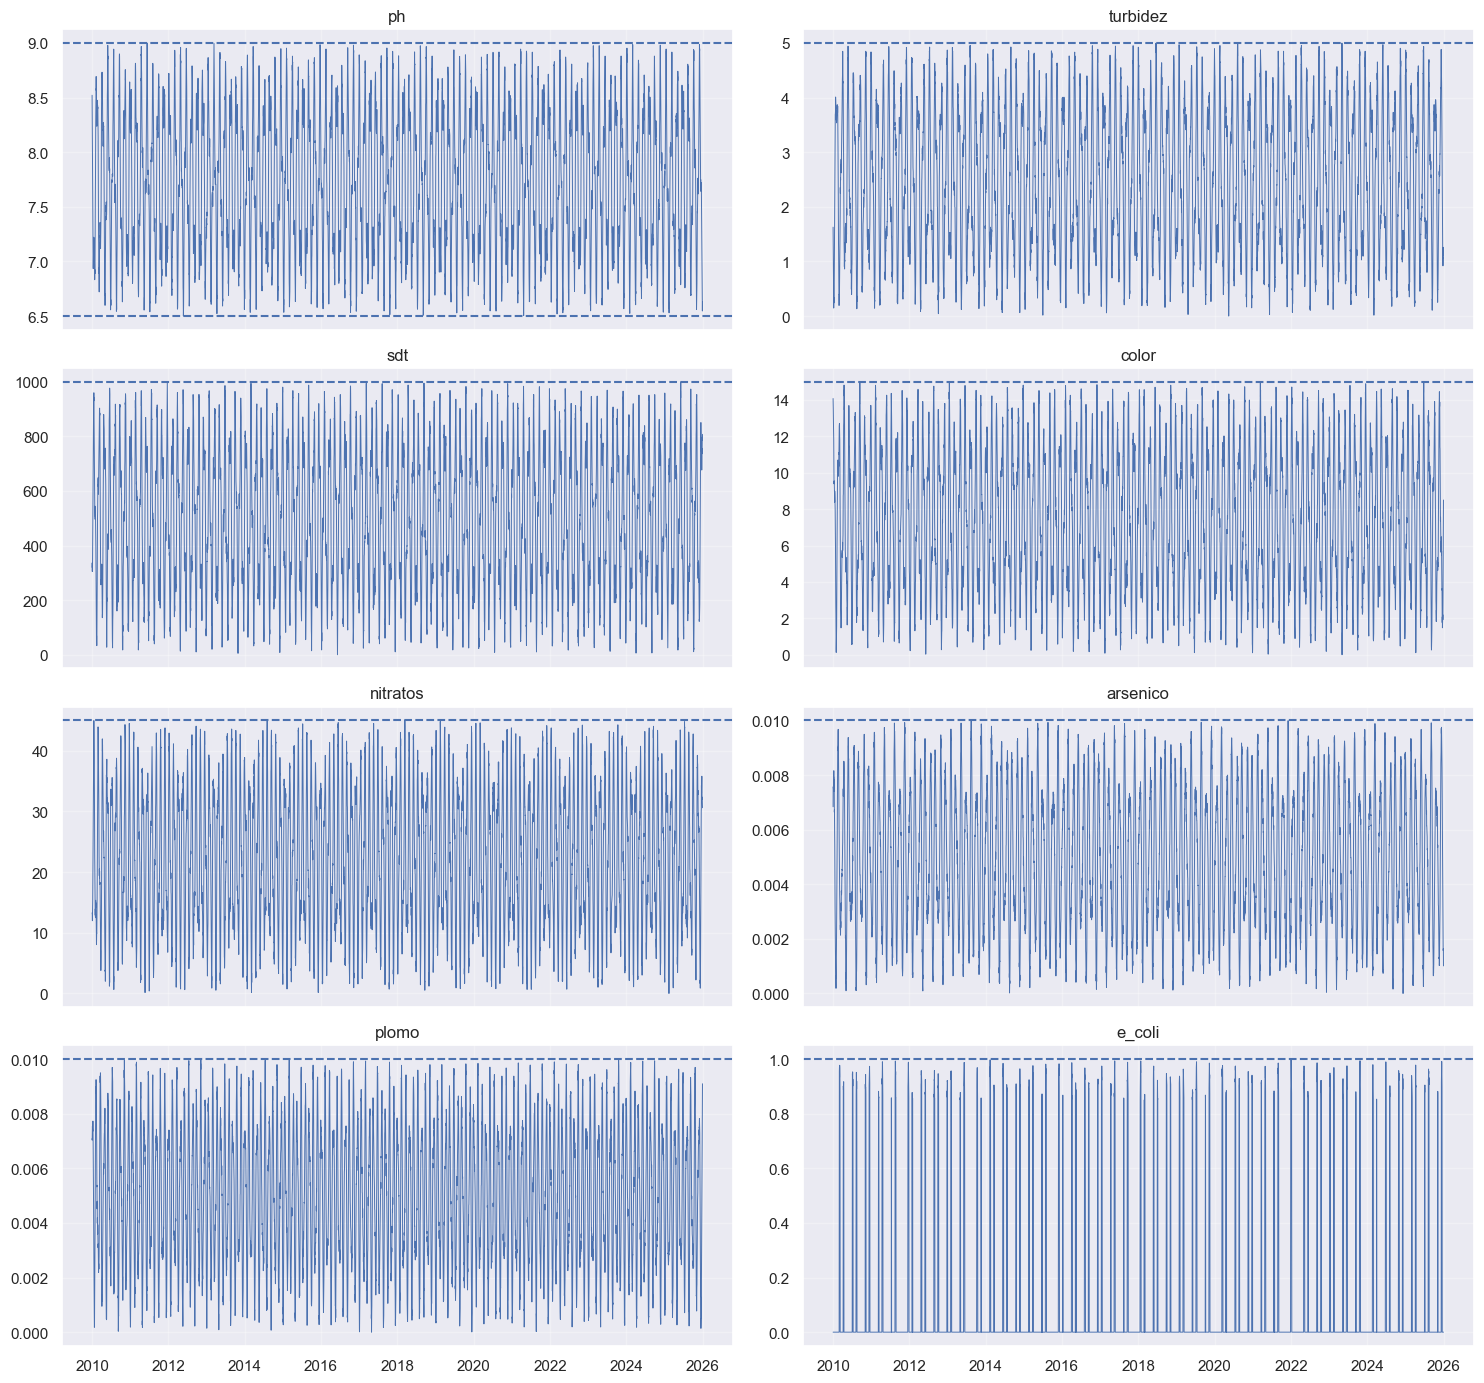

In [24]:
variables = [
    "ph",
    "turbidez",
    "sdt",
    "color",
    "nitratos",
    "arsenico",
    "plomo",
    "e_coli"
]

fig, axes = plt.subplots(
    4,
    2,
    figsize=(15, 14),
    sharex=True
)

axes = axes.flatten()

for ax, variable in zip(axes, variables):
    ax.plot(df.index, df[variable], linewidth=0.7)
    ax.set_title(variable)
    ax.grid(alpha=0.3)

# Límites
axes[0].axhline(6.5, linestyle="--")
axes[0].axhline(9.0, linestyle="--")

axes[1].axhline(5, linestyle="--")
axes[2].axhline(1000, linestyle="--")
axes[3].axhline(15, linestyle="--")
axes[4].axhline(45, linestyle="--")
axes[5].axhline(0.01, linestyle="--")
axes[6].axhline(0.01, linestyle="--")
axes[7].axhline(1, linestyle="--")

plt.tight_layout()
plt.show()

In [25]:
features = [
    "ph",
    "turbidez",
    "sdt",
    "color",
    "nitratos",
    "arsenico",
    "plomo",
    "e_coli"
]

train = df.loc["2010":"2021", features].copy()
val = df.loc["2022":"2023", features].copy()
test = df.loc["2024":"2025", features].copy()

print("Train:", train.shape)
print("Validación:", val.shape)
print("Test:", test.shape)

Train: (4383, 8)
Validación: (730, 8)
Test: (731, 8)


In [26]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train)

val_scaled = scaler.transform(val)

test_scaled = scaler.transform(test)

In [27]:
WINDOW_SIZE = 30

In [28]:
def crear_secuencias(datos, ventana=30):

    X = []
    y = []

    for i in range(ventana, len(datos)):

        X.append(
            datos[i-ventana:i]
        )

        y.append(
            datos[i]
        )

    return np.array(X), np.array(y)

X_train, y_train = crear_secuencias(
    train_scaled,
    WINDOW_SIZE
)

X_val, y_val = crear_secuencias(
    val_scaled,
    WINDOW_SIZE
)

X_test, y_test = crear_secuencias(
    test_scaled,
    WINDOW_SIZE
)

In [29]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4353, 30, 8)
y_train: (4353, 8)
X_val: (700, 30, 8)
y_val: (700, 8)
X_test: (701, 30, 8)
y_test: (701, 8)


In [31]:
print("Media aproximada de TRAIN normalizado:")
print(np.round(train_scaled.mean(axis=0), 3))

print("\nDesviación estándar aproximada:")
print(np.round(train_scaled.std(axis=0), 3))

Media aproximada de TRAIN normalizado:
[ 0.  0. -0.  0. -0.  0. -0. -0.]

Desviación estándar aproximada:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [32]:
# Obtenemos las dimensiones automáticamente de tus datos
ventana = X_train.shape[1]           # WINDOW_SIZE = 30
n_caracteristicas = X_train.shape[2] # 8 variables

# Construcción del modelo SimpleRNN
modelo_rnn = Sequential([
    # Capa recurrente: 64 neuronas. 'tanh' es la activación estándar para RNNs.
    SimpleRNN(64, activation='tanh', input_shape=(ventana, n_caracteristicas)),
    
    # Capa oculta para procesar los patrones encontrados por la RNN
    Dense(32, activation='relu'),
    
    # Capa de salida: 8 neuronas (una para cada indicador de calidad del agua)
    Dense(n_caracteristicas) 
])

modelo_rnn.summary()

c:\Users\ASUS TUF GAMING A15\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,016 (27.41 KB)

 Trainable params: 7,016 (27.41 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Compilamos usando Error Cuadrático Medio (estándar para regresión)
modelo_rnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'] # Error Absoluto Medio para que sea más interpretable
)

# Callbacks para controlar el entrenamiento
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, # Si la validación no mejora en 10 épocas, se detiene
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,  # Reduce la tasa de aprendizaje al 20% si se estanca
    patience=5, 
    min_lr=0.0001
)

In [34]:
historial = modelo_rnn.fit(
    X_train, y_train,
    epochs=100,          # Máximo de épocas (EarlyStopping lo detendrá antes si es necesario)
    batch_size=64,       # Procesa de 64 en 64 secuencias
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.8302 - mae: 0.7071 - val_loss: 0.2777 - val_mae: 0.3996 - learning_rate: 0.0010
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2154 - mae: 0.3420 - val_loss: 0.1452 - val_mae: 0.2730 - learning_rate: 0.0010
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1238 - mae: 0.2434 - val_loss: 0.1039 - val_mae: 0.2192 - learning_rate: 0.0010
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0959 - mae: 0.2028 - val_loss: 0.0874 - val_mae: 0.1934 - learning_rate: 0.0010
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0835 - mae: 0.1819 - val_loss: 0.0793 - val_mae: 0.1799 - learning_rate: 0.0010
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0771 - mae: 0.1699 - val_loss: 0.0746 - val_mae: 0.1717 - learning_rate: 0.0010
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0729 - mae: 0.1618 - val_loss: 0.0714 - val_mae: 0.1661 - learning_rate: 0.0010
Epoch 8/100


In [35]:
loss_test, mae_test = modelo_rnn.evaluate(X_test, y_test, verbose=0)
print(f"\nEvaluación en Test -> MSE: {loss_test:.4f}, MAE: {mae_test:.4f}")


Evaluación en Test -> MSE: 0.0578, MAE: 0.1298


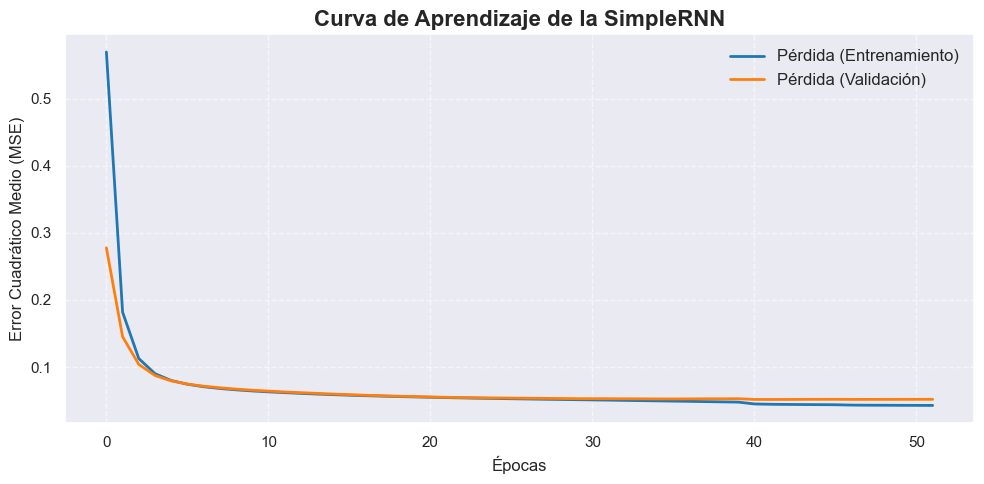

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


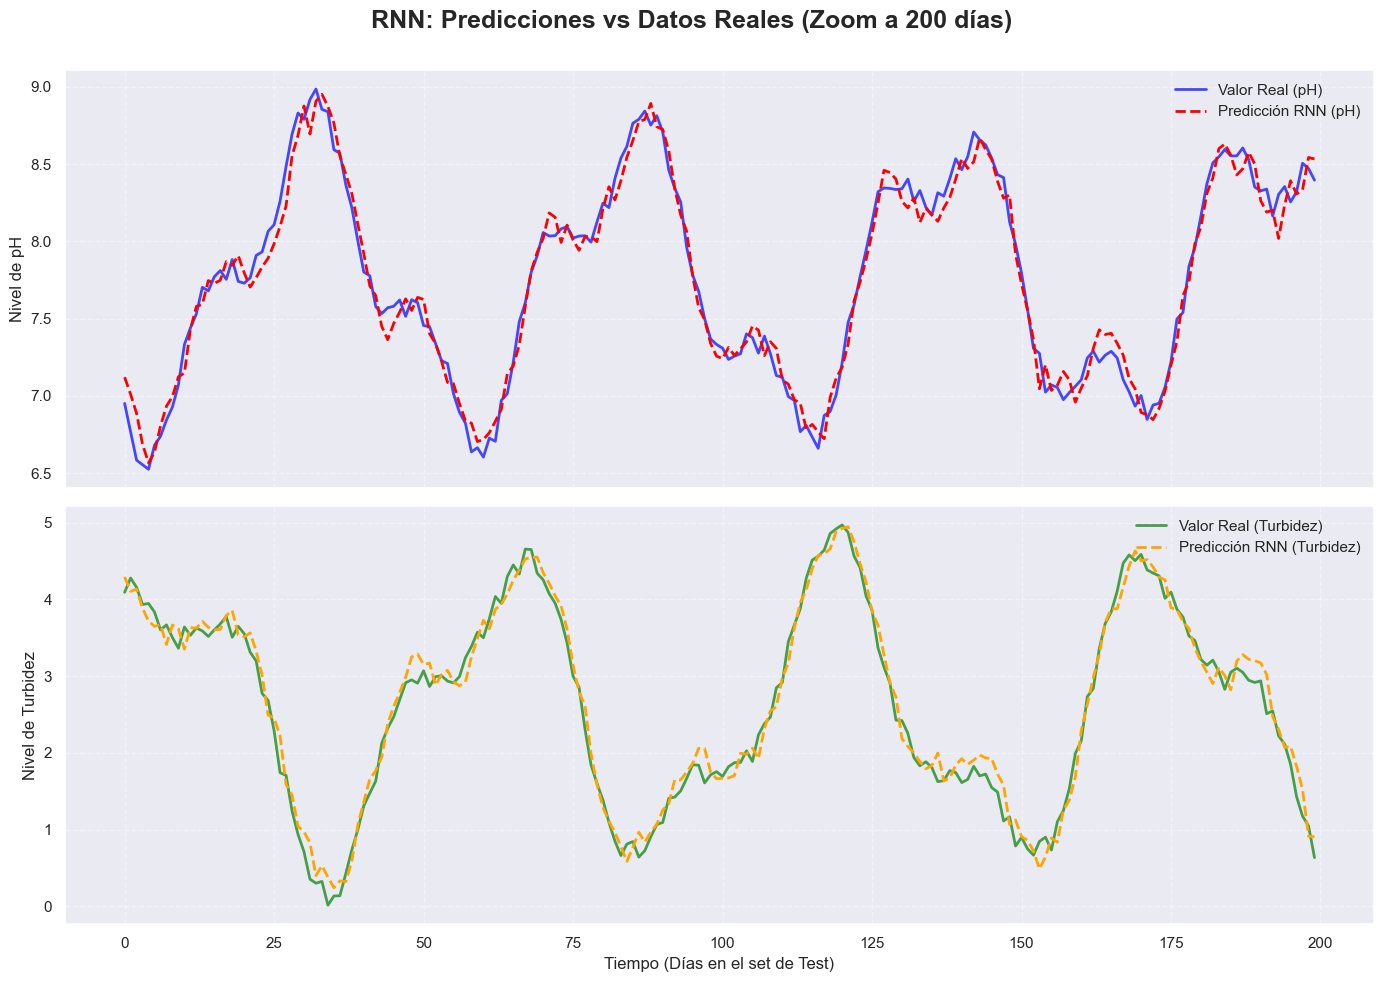

In [37]:
# ==========================================
# 1. HISTORIAL DE ENTRENAMIENTO (LOSS)
# ==========================================

plt.figure(figsize=(10, 5))
# Extraemos el MSE de entrenamiento y validación
plt.plot(historial.history['loss'], label='Pérdida (Entrenamiento)', color='#1f77b4', linewidth=2)
plt.plot(historial.history['val_loss'], label='Pérdida (Validación)', color='#ff7f0e', linewidth=2)

plt.title('Curva de Aprendizaje de la SimpleRNN', fontsize=16, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 2. PREDICCIONES E INVERSIÓN DEL ESCALADO
# ==========================================

# Generamos las predicciones con los datos que el modelo nunca ha visto
predicciones_escaladas = modelo_rnn.predict(X_test)

# Invertimos el escalado para volver a las unidades reales
predicciones_reales = scaler.inverse_transform(predicciones_escaladas)
y_test_real = scaler.inverse_transform(y_test)

# ==========================================
# 3. GRÁFICA DE PREDICCIÓN VS REAL (ZOOM)
# ==========================================

# Índices de las variables según tu lista 'features': 0 es pH, 1 es Turbidez
idx_ph = 0
idx_turbidez = 1

# Definimos cuántos pasos (días) queremos ver para que las líneas sean claras
dias_a_graficar = 200 

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)
fig.suptitle(f'RNN: Predicciones vs Datos Reales (Zoom a {dias_a_graficar} días)', fontsize=18, fontweight='bold')

# --- Gráfica para el pH ---
axes[0].plot(y_test_real[:dias_a_graficar, idx_ph], label='Valor Real (pH)', color='blue', alpha=0.7, linewidth=2)
axes[0].plot(predicciones_reales[:dias_a_graficar, idx_ph], label='Predicción RNN (pH)', color='red', linestyle='--', linewidth=2)
axes[0].set_ylabel('Nivel de pH', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Gráfica para la Turbidez ---
axes[1].plot(y_test_real[:dias_a_graficar, idx_turbidez], label='Valor Real (Turbidez)', color='green', alpha=0.7, linewidth=2)
axes[1].plot(predicciones_reales[:dias_a_graficar, idx_turbidez], label='Predicción RNN (Turbidez)', color='orange', linestyle='--', linewidth=2)
axes[1].set_ylabel('Nivel de Turbidez', fontsize=12)
axes[1].set_xlabel('Tiempo (Días en el set de Test)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()